In [1]:
import importlib, subprocess, sys

REQUIRED = ["qiskit", "qiskit_aer", "qiskit_machine_learning", "sklearn", "scipy",
            "statsmodels", "pandas", "matplotlib", "seaborn"]
PIP_NAMES = {"qiskit_aer": "qiskit-aer", "qiskit_machine_learning": "qiskit-machine-learning", "sklearn": "scikit-learn"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAMES.get(mod, mod))

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("Done. If this is the first install in this session, restart the kernel once, then re-run all cells.")
else:
    print("All required packages already present.")


All required packages already present.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

from statsmodels.stats.multitest import multipletests

import qiskit, qiskit_aer, qiskit_machine_learning
from qiskit.circuit.library import zz_feature_map, z_feature_map, pauli_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("All imports OK.")
print(f"qiskit {qiskit.__version__} | qiskit_aer {qiskit_aer.__version__} | qiskit_machine_learning {qiskit_machine_learning.__version__}")


All imports OK.
qiskit 2.5.0 | qiskit_aer 0.17.2 | qiskit_machine_learning 0.9.0


## 1. Configuration

In [3]:
N_QUBITS     = 4                          # PCA-reduced dimensionality
MAX_SAMPLES  = 150                        # per-dataset subsample cap (fast demo scale)
C_GRID       = [0.1, 1, 10, 100]          # SVM regularization grid
ALPHA        = 0.05                       # significance threshold
INNER_CV     = 3                          # inner folds used for nested architecture ranking (Section 4)
N_SPLITS     = 5                          # k in k-fold CV for the main audit
N_REPEATS    = 5                          # repeats of k-fold CV per seed (raise for the real run)
SEEDS        = [42, 7, 123, 2024, 99]     # multi-seed robustness check (add more for the real run)

DATASETS = ["breast_cancer", "wine", "iris_hard", "digits_4v9"]
FAMILIES = ["z", "zz", "pauli"]

# candidate architectures searched per encoding family (Section 4)
ARCH_GRID = {
    "z":     [{"reps": r, "entanglement": None} for r in [1, 2, 3]],
    "zz":    [{"reps": r, "entanglement": e} for r in [1, 2, 3] for e in ["linear", "full"]],
    "pauli": [{"reps": r, "entanglement": e} for r in [1, 2, 3] for e in ["linear", "full"]],
}

print(f"{len(DATASETS)} datasets x {len(FAMILIES)} encoding families, "
      f"{len(SEEDS)} seeds x {N_SPLITS}x{N_REPEATS} CV each = "
      f"{len(DATASETS)*len(FAMILIES)*len(SEEDS)*N_SPLITS*N_REPEATS} total paired evaluations")


4 datasets x 3 encoding families, 5 seeds x 5x5 CV each = 1500 total paired evaluations


In [4]:
def load_and_prepare(name):
    if name == "breast_cancer":
        X, y = load_breast_cancer(return_X_y=True)
    elif name == "wine":
        X, y = load_wine(return_X_y=True)
        mask = y < 2
        X, y = X[mask], y[mask]
    elif name == "iris_hard":
        X, y = load_iris(return_X_y=True)
        mask = y > 0
        X, y = X[mask], y[mask]
        y = (y == 2).astype(int)
    elif name == "digits_4v9":
        X, y = load_digits(return_X_y=True)
        mask = (y == 4) | (y == 9)
        X, y = X[mask], y[mask]
        y = (y == 9).astype(int)
    else:
        raise ValueError(f"Unknown dataset: {name}")

    if len(X) > MAX_SAMPLES:
        rng = np.random.RandomState(0)
        idx = rng.choice(len(X), MAX_SAMPLES, replace=False)
        X, y = X[idx], y[idx]

    X = PCA(n_components=N_QUBITS, random_state=0).fit_transform(X)
    X = MinMaxScaler((0, np.pi)).fit_transform(X)
    return X, y

DATA_CACHE = {ds: load_and_prepare(ds) for ds in DATASETS}
for name, (X, y) in DATA_CACHE.items():
    print(f"{name:15s}  n={len(X):4d}  dims={X.shape[1]}  class balance={np.bincount(y)}")


breast_cancer    n= 150  dims=4  class balance=[55 95]
wine             n= 130  dims=4  class balance=[59 71]
iris_hard        n= 100  dims=4  class balance=[50 50]
digits_4v9       n= 150  dims=4  class balance=[76 74]


In [5]:
def get_feature_map(family, n_qubits, reps, entanglement):
    if family == "z":
        return z_feature_map(feature_dimension=n_qubits, reps=reps)
    elif family == "zz":
        return zz_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement)
    elif family == "pauli":
        return pauli_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement,
                                  paulis=["Z", "ZZ", "ZZZ"])
    raise ValueError(f"Unknown family: {family}")

def compute_kernel(X, family, reps, entanglement):
    fm = get_feature_map(family, X.shape[1], reps, entanglement)
    qk = FidelityStatevectorKernel(feature_map=fm)
    return qk.evaluate(x_vec=X)

print("Feature map / kernel builders ready.")


Feature map / kernel builders ready.


In [6]:
def build_kernel_cache(X, family):
    return {(c["reps"], c["entanglement"]): compute_kernel(X, family, c["reps"], c["entanglement"])
            for c in ARCH_GRID[family]}

def select_architecture_nested(train_idx, y_train, kernel_cache, inner_seed):
    best = None
    skf = StratifiedKFold(n_splits=INNER_CV, shuffle=True, random_state=inner_seed)
    for (reps, ent), K_full in kernel_cache.items():
        scores = []
        for tr_i, val_i in skf.split(train_idx, y_train):
            tr_g, val_g = train_idx[tr_i], train_idx[val_i]
            clf = SVC(kernel="precomputed", C=1.0).fit(K_full[np.ix_(tr_g, tr_g)], y_train[tr_i])
            scores.append(clf.score(K_full[np.ix_(val_g, tr_g)], y_train[val_i]))
        mean_score = np.mean(scores)
        if best is None or mean_score > best["score"]:
            best = {"reps": reps, "entanglement": ent, "score": mean_score}
    return best

print("Nested architecture-search functions ready (kernel caches built per dataset/family below).")


Nested architecture-search functions ready (kernel caches built per dataset/family below).


In [7]:
def nadeau_bengio_corrected_ttest(diffs, n_train, n_test):
    n = len(diffs)
    mean_d = np.mean(diffs)
    var_d = np.var(diffs, ddof=1)
    corrected_var = var_d * (1.0 / n + n_test / n_train)
    if corrected_var <= 0:
        return 0.0, 1.0, (mean_d, mean_d)
    se = np.sqrt(corrected_var)
    t_stat = mean_d / se
    df = n - 1
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))
    t_crit = stats.t.ppf(1 - ALPHA / 2, df)
    ci = (mean_d - t_crit * se, mean_d + t_crit * se)
    return t_stat, p_value, ci

def cohens_d_paired(diffs):
    sd = np.std(diffs, ddof=1)
    return np.mean(diffs) / sd if sd > 0 else 0.0

print("Statistical testing functions ready.")


Statistical testing functions ready.


In [8]:
def run_comparison_nested(X, y, kernel_cache, seed, n_splits=N_SPLITS, n_repeats=N_REPEATS):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    classical_scores, quantum_scores, chosen = [], [], []
    classical_bal_scores, quantum_bal_scores = [], []
    n_train_last = n_test_last = None
    fold_i = 0

    for train_idx, test_idx in rskf.split(X, y):
        y_train, y_test = y[train_idx], y[test_idx]
        n_train_last, n_test_last = len(train_idx), len(test_idx)

        clf_c = GridSearchCV(SVC(kernel="rbf"), {"C": C_GRID}, cv=3)
        clf_c.fit(X[train_idx], y_train)
        classical_scores.append(clf_c.score(X[test_idx], y_test))
        classical_bal_scores.append(balanced_accuracy_score(y_test, clf_c.predict(X[test_idx])))

        best_arch = select_architecture_nested(train_idx, y_train, kernel_cache, inner_seed=seed * 100 + fold_i)
        chosen.append((best_arch["reps"], best_arch["entanglement"]))
        K_full = kernel_cache[(best_arch["reps"], best_arch["entanglement"])]
        K_train = K_full[np.ix_(train_idx, train_idx)]
        K_test = K_full[np.ix_(test_idx, train_idx)]
        clf_q = GridSearchCV(SVC(kernel="precomputed"), {"C": C_GRID}, cv=3)
        clf_q.fit(K_train, y_train)
        quantum_scores.append(clf_q.score(K_test, y_test))
        quantum_bal_scores.append(balanced_accuracy_score(y_test, clf_q.predict(K_test)))
        fold_i += 1

    classical_scores = np.array(classical_scores)
    quantum_scores = np.array(quantum_scores)
    diffs = quantum_scores - classical_scores

    t_stat, nb_p, ci = nadeau_bengio_corrected_ttest(diffs, n_train_last, n_test_last)
    d = cohens_d_paired(diffs)
    try:
        _, wil_p = stats.wilcoxon(diffs)
    except ValueError:
        wil_p = 1.0
    modal_arch = pd.Series(chosen).mode()[0]

    return {
        "classical_mean": classical_scores.mean(), "quantum_mean": quantum_scores.mean(),
        "mean_diff": diffs.mean(), "ci_low": ci[0], "ci_high": ci[1], "cohens_d": d,
        "nb_t_stat": t_stat, "nb_p_raw": nb_p, "wilcoxon_p_raw": wil_p,
        "modal_reps": modal_arch[0], "modal_entanglement": modal_arch[1],
        "arch_agreement_rate": round(chosen.count(modal_arch) / len(chosen), 3),
        "classical_balanced_mean": np.mean(classical_bal_scores),
        "quantum_balanced_mean": np.mean(quantum_bal_scores),
        "balanced_mean_diff": np.mean(quantum_bal_scores) - np.mean(classical_bal_scores),
    }

t1 = time.time()
rows = []
for ds in DATASETS:
    X, y = DATA_CACHE[ds]
    for fam in FAMILIES:
        kernel_cache = build_kernel_cache(X, fam)
        for seed in SEEDS:
            res = run_comparison_nested(X, y, kernel_cache, seed)
            res.update({"dataset": ds, "encoding": fam, "seed": seed})
            rows.append(res)
print(f"Multi-seed nested audit finished in {time.time()-t1:.1f}s "
      f"({len(SEEDS)} seeds x {len(DATASETS)} datasets x {len(FAMILIES)} encodings = {len(rows)} runs). "
      f"This will take noticeably longer than the single-pass version -- that's expected.")

raw_df = pd.DataFrame(rows)
raw_df["modal_entanglement"] = raw_df["modal_entanglement"].fillna("none")
_, raw_df["nb_p_holm"], _, _ = multipletests(raw_df["nb_p_raw"], alpha=ALPHA, method="holm")
raw_df["significant"] = raw_df["nb_p_holm"] < ALPHA
raw_df.head(10)


Multi-seed nested audit finished in 59.3s (5 seeds x 4 datasets x 3 encodings = 60 runs). This will take noticeably longer than the single-pass version -- that's expected.


   classical_mean  quantum_mean  mean_diff  ...  seed  nb_p_holm  significant
0        0.957333      0.944000  -0.013333  ...    42   1.000000        False
1        0.962667      0.949333  -0.013333  ...     7   1.000000        False
2        0.953333      0.938667  -0.014667  ...   123   1.000000        False
3        0.956000      0.946667  -0.009333  ...  2024   1.000000        False
4        0.958667      0.944000  -0.014667  ...    99   1.000000        False
5        0.957333      0.821333  -0.136000  ...    42   0.006362         True
6        0.962667      0.857333  -0.105333  ...     7   0.001850         True
7        0.953333      0.856000  -0.097333  ...   123   0.080275        False
8        0.956000      0.838667  -0.117333  ...  2024   0.020273         True
9        0.958667      0.853333  -0.105333  ...    99   0.056040        False

[10 rows x 20 columns]

In [9]:
def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) else x.iloc[0]

agg = raw_df.groupby(["dataset", "encoding"]).agg(
    classical_mean=("classical_mean", "mean"), quantum_mean=("quantum_mean", "mean"),
    mean_diff_avg=("mean_diff", "mean"), mean_diff_std_across_seeds=("mean_diff", "std"),
    cohens_d_avg=("cohens_d", "mean"),
    n_seeds_significant=("significant", "sum"), n_seeds_total=("significant", "count"),
    modal_reps=("modal_reps", safe_mode), modal_entanglement=("modal_entanglement", safe_mode),
    arch_agreement_avg=("arch_agreement_rate", "mean"),
    classical_balanced_mean=("classical_balanced_mean", "mean"),
    quantum_balanced_mean=("quantum_balanced_mean", "mean"),
    balanced_mean_diff_avg=("balanced_mean_diff", "mean"),
).reset_index()
agg["stability"] = agg["n_seeds_significant"].astype(str) + "/" + agg["n_seeds_total"].astype(str)
agg["verdict"] = np.select(
    [agg["n_seeds_significant"] == agg["n_seeds_total"], agg["n_seeds_significant"] == 0],
    ["stable significant difference", "stable no difference"],
    default="seed-sensitive -- inconclusive",
)
agg.round(3)


          dataset encoding  ...  stability                         verdict
0   breast_cancer    pauli  ...        5/5   stable significant difference
1   breast_cancer        z  ...        0/5            stable no difference
2   breast_cancer       zz  ...        3/5  seed-sensitive -- inconclusive
3      digits_4v9    pauli  ...        5/5   stable significant difference
4      digits_4v9        z  ...        0/5            stable no difference
5      digits_4v9       zz  ...        5/5   stable significant difference
6       iris_hard    pauli  ...        3/5  seed-sensitive -- inconclusive
7       iris_hard        z  ...        0/5            stable no difference
8       iris_hard       zz  ...        1/5  seed-sensitive -- inconclusive
9            wine    pauli  ...        5/5   stable significant difference
10           wine        z  ...        0/5            stable no difference
11           wine       zz  ...        5/5   stable significant difference

[12 rows x 17 columns]

In [10]:
imbalanced_check = agg[agg["dataset"].isin(["breast_cancer", "wine"])].copy()
imbalanced_check["accuracy_drop"] = imbalanced_check["classical_mean"] - imbalanced_check["quantum_mean"]
imbalanced_check["balanced_accuracy_drop"] = imbalanced_check["classical_balanced_mean"] - imbalanced_check["quantum_balanced_mean"]
imbalanced_check["drop_difference"] = (imbalanced_check["balanced_accuracy_drop"] - imbalanced_check["accuracy_drop"]).abs()

max_drop_diff = imbalanced_check["drop_difference"].max()
print("Balanced-accuracy robustness check (Breast Cancer Wisconsin, Wine):")
print(f"Largest |balanced-accuracy drop - plain-accuracy drop| across these 6 rows: {max_drop_diff:.4f}")
if max_drop_diff < 0.02:
    print("The two metrics track each other closely -- the three-tier pattern is not an artifact "
          "of class imbalance for these datasets.")
else:
    print("Balanced accuracy diverges from plain accuracy by a non-trivial amount for at least one "
          "row below -- inspect the table before treating the accuracy-based verdicts as imbalance-robust.")

imbalanced_check[["dataset", "encoding", "classical_mean", "quantum_mean", "accuracy_drop",
                   "classical_balanced_mean", "quantum_balanced_mean", "balanced_accuracy_drop",
                   "verdict"]].round(4)


Balanced-accuracy robustness check (Breast Cancer Wisconsin, Wine):
Largest |balanced-accuracy drop - plain-accuracy drop| across these 6 rows: 0.0413
Balanced accuracy diverges from plain accuracy by a non-trivial amount for at least one row below -- inspect the table before treating the accuracy-based verdicts as imbalance-robust.


          dataset  ...                         verdict
0   breast_cancer  ...   stable significant difference
1   breast_cancer  ...            stable no difference
2   breast_cancer  ...  seed-sensitive -- inconclusive
9            wine  ...   stable significant difference
10           wine  ...            stable no difference
11           wine  ...   stable significant difference

[6 rows x 9 columns]

In [11]:
LITERATURE_REPORTED = [
    {"dataset": "iris_hard", "encoding": "zz", "classical_reported": 1.00, "quantum_reported": 0.85,
     "source": "Naresh & Reddi (2025), Quantum Information Processing",
     "note": "original task was standard 3-class Iris, not the binarized hard pair used here -- illustrative only"},
    {"dataset": "iris_hard", "encoding": "zz", "classical_reported": 0.856, "quantum_reported": 0.679,
     "source": "Date et al. (2025), Quantum Machine Intelligence",
     "note": "exact class-pair match (versicolor vs virginica) -- but their QSVM is D-Wave adiabatic/annealing-based, not gate-based fidelity kernel like ours; algorithmic caveat, not just a task caveat"},
    {"dataset": "iris_hard", "encoding": "zz", "classical_reported": 0.99, "quantum_reported": 0.99,
     "source": "Ranga et al. (2025), Physica Scripta",
     "note": "original task was standard 3-class Iris with all 4 features, not the binarized hard pair -- illustrative only"},
    {"dataset": "wine", "encoding": "zz", "classical_reported": 0.97, "quantum_reported": 0.97,
     "source": "Naresh & Reddi (2025), Quantum Information Processing",
     "note": "original task used all 3 Wine classes and 12 features; here restricted to 2 classes, 4 PCA components"},
    {"dataset": "breast_cancer", "encoding": "zz", "classical_reported": 0.94, "quantum_reported": 0.92,
     "source": "Naresh & Reddi (2025), Quantum Information Processing",
     "note": "close match in task definition (binary Breast Cancer Wisconsin)"},
    {"dataset": "breast_cancer", "encoding": "z", "classical_reported": 0.9737, "quantum_reported": 0.947,
     "source": "Yadav, Sheoran & Sheoran (2026), PeerJ Computer Science",
     "note": "original used top-7 mutual-information features, not 4 PCA components -- illustrative only"},
]

audit_rows = []
for lit in LITERATURE_REPORTED:
    ds, enc = lit["dataset"], lit["encoding"]
    ours = agg[(agg.dataset == ds) & (agg.encoding == enc)].iloc[0]
    lit_diff = lit["quantum_reported"] - lit["classical_reported"]
    lit_verdict = "reported as a tie" if abs(lit_diff) < 0.01 else ("reported quantum win" if lit_diff > 0 else "reported classical win")
    audit_rows.append({
        "dataset": ds, "encoding": enc, "source": lit["source"],
        "reported_classical": lit["classical_reported"], "reported_quantum": lit["quantum_reported"],
        "reported_verdict": lit_verdict,
        "our_classical": round(ours["classical_mean"], 3), "our_quantum": round(ours["quantum_mean"], 3),
        "our_stability": ours["stability"], "our_verdict": ours["verdict"], "note": lit["note"],
    })

audit_df = pd.DataFrame(audit_rows)
audit_df


         dataset  ...                                               note
0      iris_hard  ...  original task was standard 3-class Iris, not t...
1      iris_hard  ...  exact class-pair match (versicolor vs virginic...
2      iris_hard  ...  original task was standard 3-class Iris with a...
3           wine  ...  original task used all 3 Wine classes and 12 f...
4  breast_cancer  ...  close match in task definition (binary Breast ...
5  breast_cancer  ...  original used top-7 mutual-information feature...

[6 rows x 11 columns]

In [12]:
COVERAGE = [
    (1,  "Choi et al. -- COVID-19 biomarkers",              "Restricted",        "INCOV cohort is public (linked to Su et al., Cell 2022), but full replication also needs the Cleveland Clinic cohort, released only 'on reasonable request'"),
    (2,  "Zarbipour et al. -- wave overtopping",             "Restricted",        "CLASH database access is granted via registration with the originating research consortium, not an open download; also a regression, not classification, task"),
    (3,  "Franco et al. -- quantum phase classification",    "Requires simulation", "requires simulating ANNNI-model ground states rather than downloading data"),
    (4,  "Yadav et al. -- breast cancer diagnosis",           "Included",         "Breast Cancer Wisconsin is publicly bundled and loadable offline"),
    (5,  "Xu et al. -- algorithmic survey",                   "Public, task mismatch", "Iris is public, but their demos used only 8-16 samples -- too small to be a meaningful comparison at our audit scale"),
    (6,  "Wankhede et al. -- financial predictions",          "Public, not fetched", "S&P 500 prices and macroeconomic indicators are broadly public (e.g. via Yahoo Finance, FRED) but require an internet fetch not available here"),
    (7,  "Shahid et al. -- movie recommendations",            "Public, not fetched", "IMDB movie data is a public Kaggle dataset (~25M records), not fetched here due to size and no internet access"),
    (8,  "Wang & Cao -- quantum phase transition",            "Requires simulation", "requires simulating physical Hamiltonians rather than downloading data"),
    (9,  "El Ayachi & El Baz -- multipartite entanglement",   "Partial",           "uses public datasets (Iris, Digits, Breast Cancer, Titanic, Blood Transfusion, Palmer Penguins, Fashion-MNIST) but our extracted summary lacks precise per-dataset accuracy figures to cite exactly"),
    (10, "Lalawat et al. -- EEG motor imagery",               "Public, not fetched", "BCI Competition IV Dataset 2a is a standard public EEG benchmark, not fetched here due to no internet access"),
    (11, "Ranga et al. -- Iris/Wine empirical study",         "Included",          "Iris and Wine are publicly bundled and loadable offline"),
    (12, "Abdulsalam & Ahmad -- kernel comparison",           "Public, not fetched", "all 11 datasets (Cleveland Heart Disease, Glass, Concrete, Abalone, Auto MPG, etc.) are classic public UCI repository sets, not fetched here due to no internet access"),
    (13, "Sharma et al. -- cross-domain quantum states",      "Requires simulation", "requires generating synthetic quantum states via QuTiP rather than downloading data"),
    (14, "Bayro & Jeong -- VR affective computing",           "Restricted",        "original, unpublished human-subjects dataset -- not released publicly"),
    (15, "Date et al. -- adiabatic QSVM",                     "Included",          "Iris (among others) is publicly bundled and loadable offline"),
    (16, "Nadim et al. -- software bug prediction",           "Public, not fetched", "commit histories are mined from public open-source repositories, not fetched here due to no internet access"),
    (17, "Naresh & Reddi -- healthcare predictive analytics", "Included",          "Wine, Breast Cancer, Iris are bundled; Diabetes (Pima Indians) and Prostate Cancer are public UCI sets but not sklearn-bundled, so excluded here specifically"),
    (18, "Akrom et al. -- blood-brain-barrier permeability",  "Public, not fetched", "the BBBP dataset is part of the public MoleculeNet benchmark suite, not fetched here due to no internet access"),
    (19, "Cattan et al. -- Parkinson's gait classification",  "Restricted",        "the internal 37-subject clinical cohort is private; the KOA-PD-NM comparison dataset is public but the study's primary result relies on the private cohort"),
    (20, "Zhou et al. -- QKE-QSVR regression",                "Public, task mismatch", "NASA airfoil self-noise is a public UCI dataset, but this is a regression task requiring a different (SVR/QSVR) pipeline, out of scope for this classification-focused audit"),
]
coverage_df = pd.DataFrame(COVERAGE, columns=["paper_no", "paper", "status", "reason"])

status_counts = coverage_df["status"].value_counts()
n_included = status_counts.get("Included", 0)
n_partial = status_counts.get("Partial", 0)
n_restricted = status_counts.get("Restricted", 0)
n_public_not_fetched = status_counts.get("Public, not fetched", 0)
n_sim = status_counts.get("Requires simulation", 0)
n_task_mismatch = status_counts.get("Public, task mismatch", 0)
total = len(coverage_df)

print("Coverage breakdown:")
print(status_counts.to_string())
print()
print(f"Direct numeric coverage rate (Included only):        {n_included}/{total} = {100*n_included/total:.0f}%")
print(f"Genuinely restricted/proprietary rate:                {n_restricted}/{total} = {100*n_restricted/total:.0f}%  <- the real field-level reproducibility barrier")
print(f"Public but not fetched in this run (tooling, not the field's fault): {n_public_not_fetched}/{total} = {100*n_public_not_fetched/total:.0f}%")
print(f"Requires re-simulating a physical system:             {n_sim}/{total} = {100*n_sim/total:.0f}%")
coverage_df


Coverage breakdown:
status
Public, not fetched      6
Restricted               4
Included                 4
Requires simulation      3
Public, task mismatch    2
Partial                  1

Direct numeric coverage rate (Included only):        4/20 = 20%
Genuinely restricted/proprietary rate:                4/20 = 20%  <- the real field-level reproducibility barrier
Public but not fetched in this run (tooling, not the field's fault): 6/20 = 30%
Requires re-simulating a physical system:             3/20 = 15%


    paper_no  ...                                             reason
0          1  ...  INCOV cohort is public (linked to Su et al., C...
1          2  ...  CLASH database access is granted via registrat...
2          3  ...  requires simulating ANNNI-model ground states ...
3          4  ...  Breast Cancer Wisconsin is publicly bundled an...
4          5  ...  Iris is public, but their demos used only 8-16...
5          6  ...  S&P 500 prices and macroeconomic indicators ar...
6          7  ...  IMDB movie data is a public Kaggle dataset (~2...
7          8  ...  requires simulating physical Hamiltonians rath...
8          9  ...  uses public datasets (Iris, Digits, Breast Can...
9         10  ...  BCI Competition IV Dataset 2a is a standard pu...
10        11  ...  Iris and Wine are publicly bundled and loadabl...
11        12  ...  all 11 datasets (Cleveland Heart Disease, Glas...
12        13  ...  requires generating synthetic quantum states v...
13        14  ...  original, unpub

## 9. Visualization

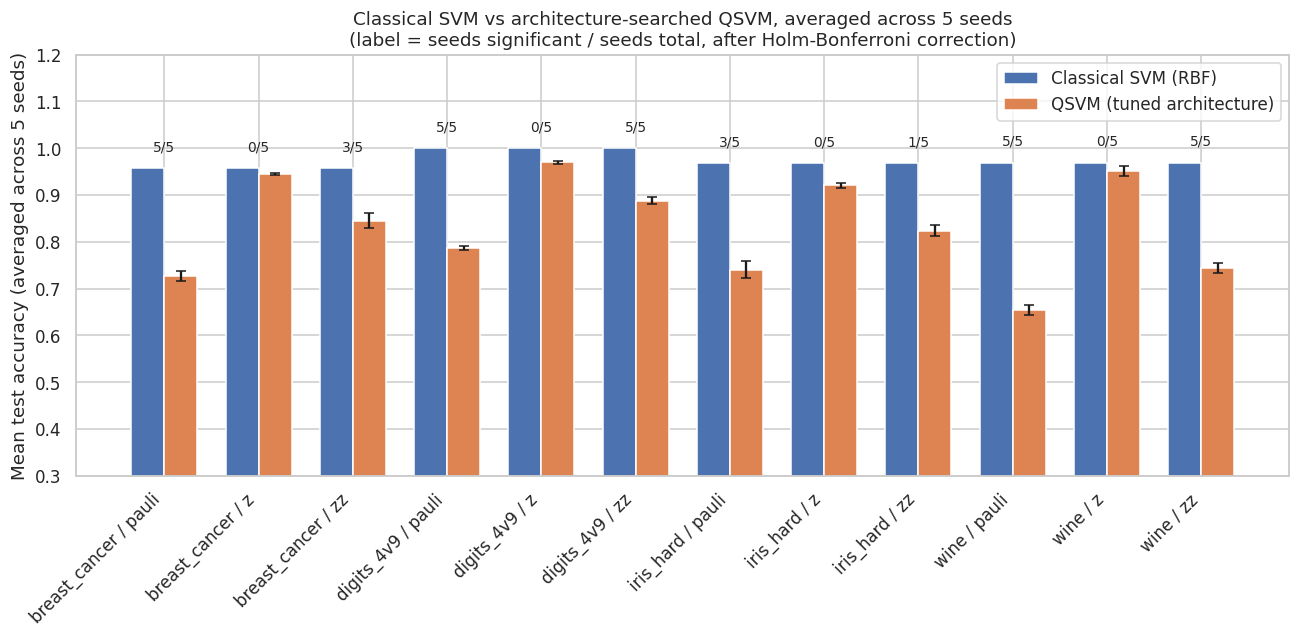

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = agg.copy()
plot_df["label"] = plot_df["dataset"] + " / " + plot_df["encoding"]

x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width/2, plot_df["classical_mean"], width, label="Classical SVM (RBF)", capsize=3)
ax.bar(x + width/2, plot_df["quantum_mean"], width,
       yerr=plot_df["mean_diff_std_across_seeds"], label="QSVM (tuned architecture)", capsize=3)

for i, row in plot_df.iterrows():
    ax.text(i, max(row["classical_mean"], row["quantum_mean"]) + 0.03, row["stability"],
            ha="center", va="bottom", fontsize=9, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylabel("Mean test accuracy (averaged across 5 seeds)")
ax.set_ylim(0.3, 1.2)
ax.set_title("Classical SVM vs architecture-searched QSVM, averaged across 5 seeds\n"
             "(label = seeds significant / seeds total, after Holm-Bonferroni correction)")
ax.legend()
plt.tight_layout()
plt.savefig("paper1_v2_accuracy_comparison.png", dpi=150)
plt.show()


## 10. Save results

In [14]:
raw_df.to_csv("paper1_v2_raw_multiseed_results.csv", index=False)
agg.to_csv("paper1_v2_aggregated_results.csv", index=False)
audit_df.to_csv("paper1_v2_literature_comparison.csv", index=False)
coverage_df.to_csv("paper1_v2_paper_coverage.csv", index=False)

n_configs = len(agg)
n_stable_sig = (agg["n_seeds_significant"] == agg["n_seeds_total"]).sum()
n_stable_null = (agg["n_seeds_significant"] == 0).sum()
n_inconclusive = n_configs - n_stable_sig - n_stable_null

n_seeds = len(SEEDS)
print(f"Total dataset x encoding configurations: {n_configs}")
print(f"Stable significant difference ({n_seeds}/{n_seeds} seeds): {n_stable_sig}")
print(f"Stable no difference (0/{n_seeds} seeds):            {n_stable_null}")
print(f"Seed-sensitive / inconclusive:                {n_inconclusive}")
print()
print("Saved: paper1_v2_raw_multiseed_results.csv, paper1_v2_aggregated_results.csv,")
print("       paper1_v2_literature_comparison.csv, paper1_v2_paper_coverage.csv,")
print("       paper1_v2_accuracy_comparison.png")


Total dataset x encoding configurations: 12
Stable significant difference (5/5 seeds): 5
Stable no difference (0/5 seeds):            4
Seed-sensitive / inconclusive:                3

Saved: paper1_v2_raw_multiseed_results.csv, paper1_v2_aggregated_results.csv,
       paper1_v2_literature_comparison.csv, paper1_v2_paper_coverage.csv,
       paper1_v2_accuracy_comparison.png


In [15]:
import sklearn, scipy, statsmodels, pandas as pd_mod, numpy as np_mod

versions = {
    "qiskit": qiskit.__version__, "qiskit-aer": qiskit_aer.__version__,
    "qiskit-machine-learning": qiskit_machine_learning.__version__,
    "scikit-learn": sklearn.__version__, "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__, "pandas": pd_mod.__version__, "numpy": np_mod.__version__,
}
with open("requirements.txt", "w") as f:
    for pkg, ver in versions.items():
        f.write(f"{pkg}=={ver}\n")

for pkg, ver in versions.items():
    print(f"{pkg}=={ver}")
print()
print("Saved: requirements.txt")


qiskit==2.5.0
qiskit-aer==0.17.2
qiskit-machine-learning==0.9.0
scikit-learn==1.7.2
scipy==1.15.3
statsmodels==0.14.6
pandas==2.3.3
numpy==2.2.6

Saved: requirements.txt
